# Tugas 14 — Analisis Faktor dengan Bayesian Network

**Kelompok :** 3   
**Anggota 1 :** Syarifah Nesia (2024091017) - TEKNIK SIPIL   
**Anggota 2 :** Panji Kurnia Akbar (2024081024) - SISTEM INFORMASI    
**Mata Kuliah:** Introduction to AI 

---

## Judul Kasus
**Analisis Faktor yang Mempengaruhi Keputusan Belanja Online**  
*(Berbasis Data Survei Perilaku Konsumen: Preferensi Belanja Online vs. Offline)*

---

## Tujuan
Notebook ini bertujuan untuk:
1. Menentukan variabel-variabel yang memengaruhi keputusan belanja online
2. Menjelaskan hubungan antar-variabel menggunakan pendekatan Bayesian Network
3. Membangun struktur Bayesian Network dari data survei nyata
4. Menerapkan **Parameter Learning** untuk menghitung probabilitas bersyarat
5. Menerapkan **Structure Learning** untuk menemukan pola hubungan dari data
6. Menarik kesimpulan berbasis probabilistik

---

## Dataset
Dataset yang digunakan merupakan hasil survei kelompok:  
**"Survei Perilaku Konsumen: Analisis Preferensi Belanja Online vs. Offline"**  
- Total responden: **102 orang**
- Metode pengumpulan: Google Form
- Variabel yang dianalisis dipilih berdasarkan relevansi terhadap keputusan belanja online

---
## Tahap 1 — Import Library

Pada tahap ini, kita mengimpor seluruh library Python yang diperlukan untuk:
- **`pandas`** & **`numpy`**: manipulasi dan analisis data
- **`matplotlib`** & **`seaborn`**: visualisasi data dan grafik
- **`networkx`**: membuat dan menggambar graf Bayesian Network
- **`scipy.stats`**: perhitungan statistik (chi-square test untuk structure learning)
- **`sklearn`**: preprocessing dan evaluasi model
- **`itertools`**, **`collections`**: utilitas Python standar

In [1]:
# ─── Standard Library ───────────────────────────────────────────────────────
import warnings
import itertools
from collections import defaultdict

# ─── Data Manipulation ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─── Graph / Network ────────────────────────────────────────────────────────
import networkx as nx

# ─── Statistics ─────────────────────────────────────────────────────────────
from scipy.stats import chi2_contingency

# ─── Global Settings ────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Tema visualisasi konsisten
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

print('✅ Semua library berhasil diimpor.')

✅ Semua library berhasil diimpor.


---
## Tahap 2 — Load & Eksplorasi Dataset

Kita memuat dataset survei perilaku konsumen dan melakukan eksplorasi awal untuk memahami:
- Jumlah baris dan kolom
- Nama setiap kolom (pertanyaan survei)
- Tipe data dan distribusi nilai
- Ada tidaknya nilai yang hilang (*missing values*)

Dataset terdiri dari **16 kolom** yang merepresentasikan pertanyaan survei mengenai perilaku belanja responden.

In [24]:
# ─── Load Dataset ────────────────────────────────────────────────────────────
FILE_PATH = 'Survei_Perilaku_Konsumen.csv'

df_raw = pd.read_csv(FILE_PATH)

print(f'Jumlah baris  : {df_raw.shape[0]} responden')
print(f'Jumlah kolom  : {df_raw.shape[1]} pertanyaan/variabel')
print()
print('─' * 60)
print('DAFTAR KOLOM:')
print('─' * 60)
for i, col in enumerate(df_raw.columns):
    print(f'  [{i:02d}] {col.strip()}')

Jumlah baris  : 102 responden
Jumlah kolom  : 16 pertanyaan/variabel

────────────────────────────────────────────────────────────
DAFTAR KOLOM:
────────────────────────────────────────────────────────────
  [00] Timestamp
  [01] Nama Lengkap
  [02] Jenis Kelamin
  [03] Usia
  [04] Pekerjaan Utama
  [05] Rata-rata Pengeluaran Belanja per Bulan
  [06] Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?
  [07] Kategori produk apa yang paling sering Anda beli secara Online?
  [08] Apa faktor utama yang membuat Anda memilih belanja Online?
  [09] Seberapa besar pengaruh "Ulasan/Review Pembeli" terhadap keputusan Anda saat belanja Online?
  [10] Saat berbelanja Offline (Toko Fisik/Mall), apa alasan utama Anda tetap melakukannya?
  [11] Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?
  [12] Apakah menurut Anda harga di toko Online jauh lebih murah dibandingkan toko Offline?
  [13] Berapa l

In [3]:
# ─── Tampilkan 5 Baris Pertama ───────────────────────────────────────────────
print('5 Baris Pertama Dataset:')
df_raw.head()

5 Baris Pertama Dataset:


,Timestamp,Nama Lengkap,Jenis Kelamin,Usia,Pekerjaan Utama,Rata-rata Pengeluaran Belanja per Bulan,Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?,Kategori produk apa yang paling sering Anda beli secara Online?,Apa faktor utama yang membuat Anda memilih belanja Online?,"Seberapa besar pengaruh ""Ulasan/Review Pembeli"" terhadap keputusan Anda saat belanja Online?","Saat berbelanja Offline (Toko Fisik/Mall), apa alasan utama Anda tetap melakukannya?",Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?,Apakah menurut Anda harga di toko Online jauh lebih murah dibandingkan toko Offline?,Berapa lama waktu yang bersedia Anda tunggu untuk pengiriman barang jika belanja secara Online?,Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?,"Secara keseluruhan, dalam kondisi normal, platform mana yang lebih Anda prioritaskan untuk belanja saat ini?"
0,06/04/2026 22:10:09,Meta,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,Rp1 Juta - Rp3 Juta,4,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses, Variasi Produk,...",5,Bisa mencoba/melihat fisik barang,3,4,4-7 Hari,4,Online Shopper
1,06/04/2026 22:11:43,M.Aldrich Ihza H. (2021) (Semangat ya),Laki-laki,18-25 Tahun,Wiraswasta,< Rp1 Juta,3,Elektronik,Diskon/Promo,5,Bisa mencoba/melihat fisik barang,5,5,2-3 Hari,5,Offline Shopper
2,06/04/2026 22:15:37,Sabrina Qurrota Aina Sunarya,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,< Rp1 Juta,4,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses",5,Bisa mencoba/melihat fisik barang,3,5,2-3 Hari,3,Online Shopper
3,06/04/2026 22:16:29,Kruisna Rikzaa Maulana,Laki-laki,18-25 Tahun,Atlet & pelatih Muaythai,< Rp1 Juta,1,Kebutuhan Pokok/Makanan,Kemudahan Akses,3,Bisa mencoba/melihat fisik barang,5,4,2-3 Hari,3,Offline Shopper
4,06/04/2026 22:18:18,LUBNAYYA ARISUNAR,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,Rp3 Juta - Rp5 Juta,5,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses, Variasi Produk,...",4,Bisa mencoba/melihat fisik barang,5,5,2-3 Hari,2,Online Shopper


In [4]:
# ─── Cek Missing Values ──────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
total_missing = missing.sum()

print(f'Total missing values: {total_missing}')
print()
if total_missing == 0:
    print('✅ Dataset bersih — tidak ada nilai yang hilang.')
else:
    print(missing[missing > 0])

Total missing values: 0

✅ Dataset bersih — tidak ada nilai yang hilang.


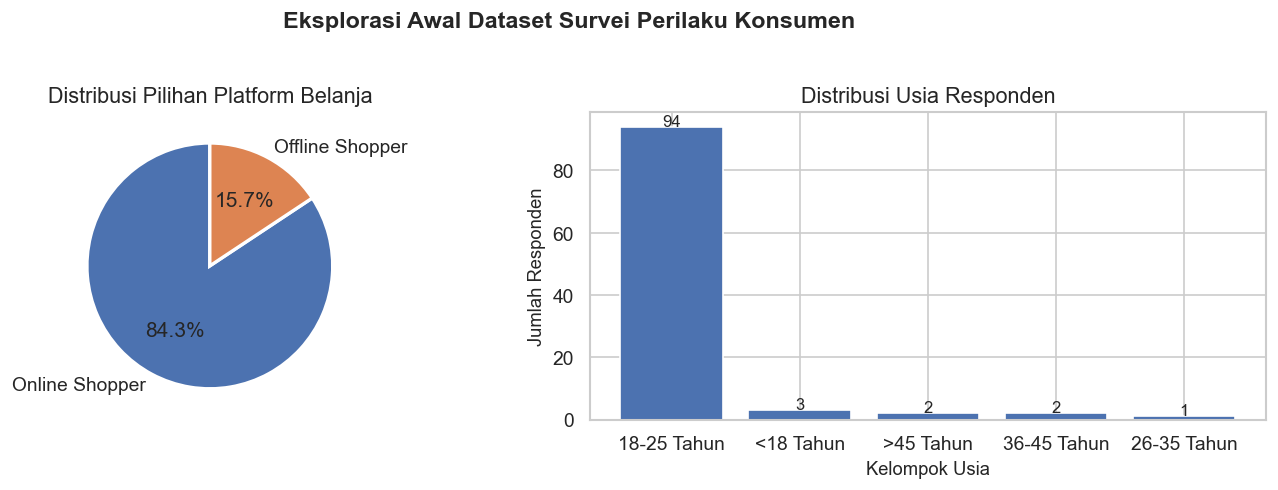


Ringkasan Platform:
  Online Shopper       : 86 responden (84.3%)
  Offline Shopper      : 16 responden (15.7%)


In [5]:
# ─── Distribusi Variabel Utama ───────────────────────────────────────────────
col_platform = 'Secara keseluruhan, dalam kondisi normal, platform mana yang lebih Anda prioritaskan untuk belanja saat ini?  '

platform_counts = df_raw[col_platform].value_counts()
pct = (platform_counts / len(df_raw) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(
    platform_counts,
    labels=platform_counts.index,
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Distribusi Pilihan Platform Belanja')

# Bar chart distribusi usia
col_usia = 'Usia  '
usia_counts = df_raw[col_usia].value_counts()
axes[1].bar(usia_counts.index, usia_counts.values, color='#4C72B0', edgecolor='white')
axes[1].set_title('Distribusi Usia Responden')
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Jumlah Responden')
for i, v in enumerate(usia_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10)

plt.suptitle('Eksplorasi Awal Dataset Survei Perilaku Konsumen', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nRingkasan Platform:')
for label, count in platform_counts.items():
    print(f'  {label.strip():20s} : {count} responden ({pct[label]:.1f}%)')

---
## Tahap 3 — Preprocessing & Definisi Variabel Bayesian Network

### Daftar Variabel (Minimal 4 Variabel)

Berdasarkan hasil survei, dipilih **6 variabel utama** yang akan digunakan dalam Bayesian Network:

| No | Nama Variabel       | Sumber Kolom Survei                                              | Transformasi              |
|----|---------------------|------------------------------------------------------------------|---------------------------|
| 1  | `ReviewPositif`     | Pengaruh ulasan/review pembeli (skala 1–5)                       | ≥ 4 → 1 (Tinggi), < 4 → 0 |
| 2  | `HargaMurah`        | Persepsi harga online lebih murah (skala 1–5)                    | ≥ 4 → 1 (Ya), < 4 → 0    |
| 3  | `RisikoRendah`      | Tingkat kekhawatiran terhadap penipuan (skala 1–5)               | ≤ 2 → 1 (Aman), > 2 → 0  |
| 4  | `AdaPromo`          | Faktor diskon/promo sebagai alasan belanja online                | Ada → 1, Tidak → 0        |
| 5  | `FrekuensiTinggi`   | Frekuensi belanja online per bulan (skala 1–5)                   | ≥ 4 → 1 (Sering), < 4 → 0|
| 6  | `BelanjaOnline`     | Preferensi platform belanja (Online Shopper / Offline Shopper)   | Online → 1, Offline → 0   |

---
### Hubungan Antar-Variabel (Struktur yang Ditetapkan)

Berdasarkan logika bisnis dan literatur perilaku konsumen:

```
ReviewPositif  ──────────────────────────┐
                                         ▼
HargaMurah     ──────────────────────► BelanjaOnline
                                         ▲
RisikoRendah   ──────────────────────────┤
                                         │
AdaPromo       ──────────────────────────┤
                                         │
FrekuensiTinggi ─────────────────────────┘
```

**Penjelasan:**
- Semua variabel faktor (`ReviewPositif`, `HargaMurah`, `RisikoRendah`, `AdaPromo`, `FrekuensiTinggi`) **memengaruhi** variabel target `BelanjaOnline`
- `BelanjaOnline` adalah variabel *child* (node anak) — nilainya bergantung pada semua variabel di atasnya
- Ini merupakan **Directed Acyclic Graph (DAG)** — tidak ada siklus

In [6]:
# ─── Definisi Nama Kolom Asli ─────────────────────────────────────────────────
COL_REVIEW    = 'Seberapa besar pengaruh "Ulasan/Review Pembeli" terhadap keputusan Anda saat belanja Online?'
COL_HARGA     = 'Apakah menurut Anda harga di toko Online jauh lebih murah dibandingkan toko Offline?'
COL_RISIKO    = 'Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?  '
COL_PROMO     = 'Apa faktor utama yang membuat Anda memilih belanja Online?'
COL_FREKUENSI = 'Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?'
COL_PLATFORM  = 'Secara keseluruhan, dalam kondisi normal, platform mana yang lebih Anda prioritaskan untuk belanja saat ini?  '

# ─── Transformasi ke Variabel Biner ──────────────────────────────────────────
data = pd.DataFrame()

data['ReviewPositif']   = (df_raw[COL_REVIEW].astype(int) >= 4).astype(int)
data['HargaMurah']      = (df_raw[COL_HARGA].astype(int) >= 4).astype(int)
data['RisikoRendah']    = (df_raw[COL_RISIKO].astype(int) <= 2).astype(int)
data['AdaPromo']        = df_raw[COL_PROMO].str.contains('Diskon/Promo', na=False).astype(int)
data['FrekuensiTinggi'] = (df_raw[COL_FREKUENSI].astype(int) >= 4).astype(int)
data['BelanjaOnline']   = (df_raw[COL_PLATFORM].str.strip() == 'Online Shopper').astype(int)

# ─── Tampilkan Ringkasan ──────────────────────────────────────────────────────
print('✅ Dataset setelah preprocessing:')
print(f'   Shape: {data.shape}')
print()

# Tabel proporsi tiap variabel
summary_rows = []
label_map = {
    'ReviewPositif'  : ('Review Rendah', 'Review Tinggi (≥4)'),
    'HargaMurah'     : ('Harga Tidak Murah', 'Harga Murah (≥4)'),
    'RisikoRendah'   : ('Risiko Tinggi', 'Risiko Rendah (≤2)'),
    'AdaPromo'       : ('Tanpa Promo', 'Ada Promo/Diskon'),
    'FrekuensiTinggi': ('Jarang (< 4)', 'Sering Belanja (≥4)'),
    'BelanjaOnline'  : ('Offline Shopper', 'Online Shopper'),
}
for col, (label0, label1) in label_map.items():
    n1 = data[col].sum()
    n0 = len(data) - n1
    pct1 = n1 / len(data) * 100
    summary_rows.append({'Variabel': col, f'0 = {label0}': n0, f'1 = {label1}': n1, '% Nilai 1': f'{pct1:.1f}%'})

summary_df = pd.DataFrame(summary_rows).set_index('Variabel')
display(summary_df)

✅ Dataset setelah preprocessing:
   Shape: (102, 6)



,0 = Review Rendah,1 = Review Tinggi (≥4),% Nilai 1,0 = Harga Tidak Murah,1 = Harga Murah (≥4),0 = Risiko Tinggi,1 = Risiko Rendah (≤2),0 = Tanpa Promo,1 = Ada Promo/Diskon,0 = Jarang (< 4),1 = Sering Belanja (≥4),0 = Offline Shopper,1 = Online Shopper
Variabel,,,,,,,,,,,,,
ReviewPositif,18.0000,84.0000,82.4%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HargaMurah,NaN,NaN,78.4%,22.0000,80.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RisikoRendah,NaN,NaN,18.6%,NaN,NaN,83.0000,19.0000,NaN,NaN,NaN,NaN,NaN,NaN
AdaPromo,NaN,NaN,76.5%,NaN,NaN,NaN,NaN,24.0000,78.0000,NaN,NaN,NaN,NaN
FrekuensiTinggi,NaN,NaN,52.9%,NaN,NaN,NaN,NaN,NaN,NaN,48.0000,54.0000,NaN,NaN
BelanjaOnline,NaN,NaN,84.3%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0000,86.0000


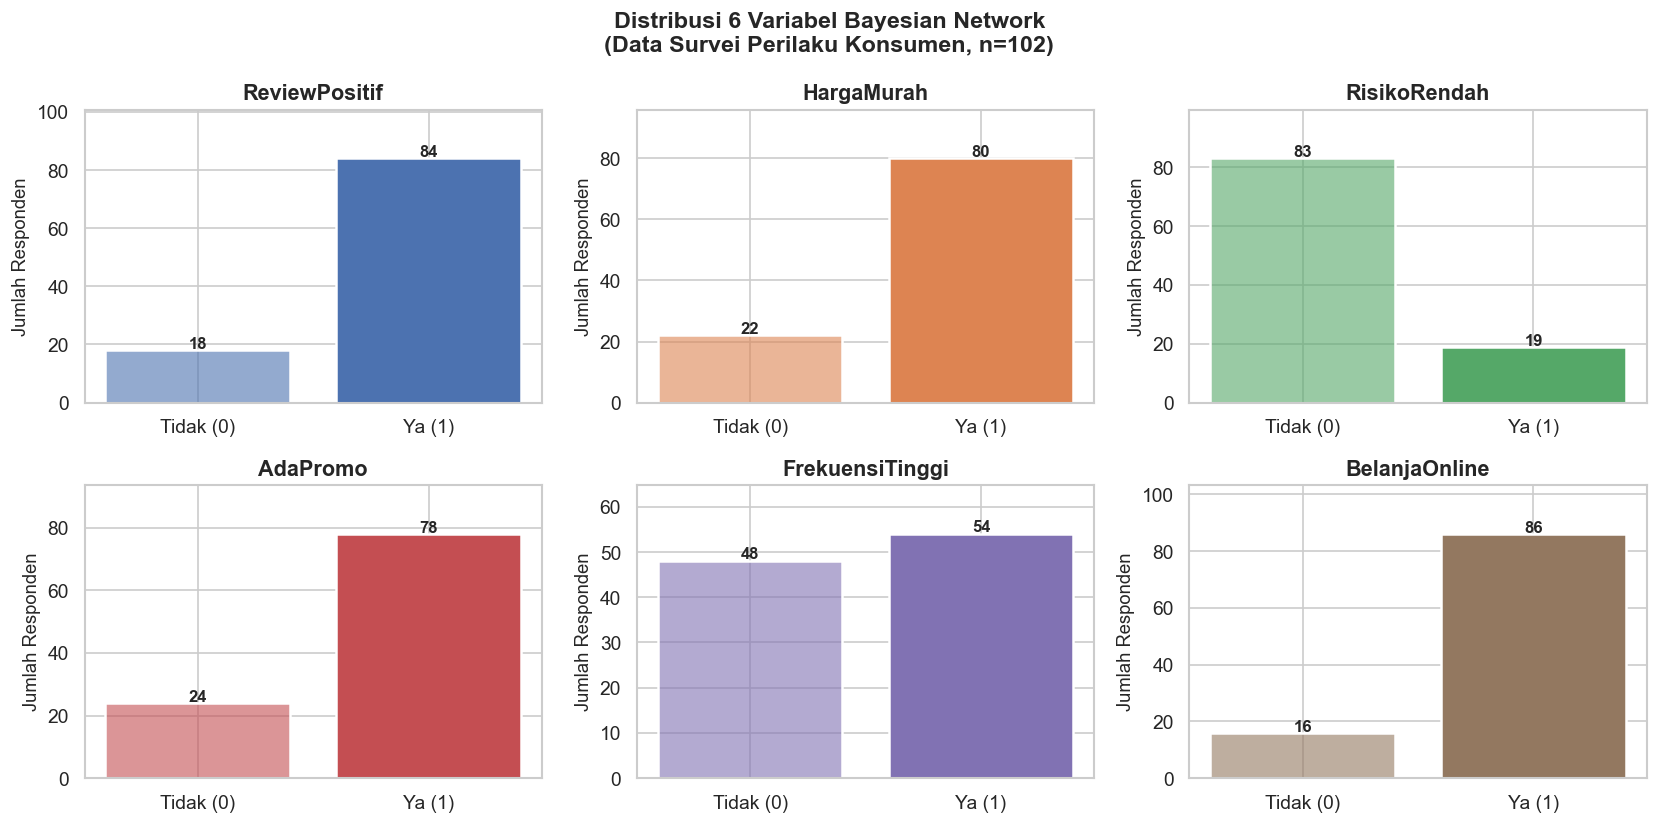

In [7]:
# ─── Visualisasi Distribusi 6 Variabel ───────────────────────────────────────
VARIABLES = list(data.columns)
COLORS    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, (var, color) in enumerate(zip(VARIABLES, COLORS)):
    counts = data[var].value_counts().sort_index()
    labels = ['Tidak (0)', 'Ya (1)']
    bars = axes[i].bar(labels[:len(counts)], counts.values, color=[color+'99', color], edgecolor='white', linewidth=1.5)
    axes[i].set_title(var, fontweight='bold')
    axes[i].set_ylabel('Jumlah Responden')
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)), ha='center', fontsize=10, fontweight='bold')
    axes[i].set_ylim(0, max(counts.values) * 1.2)

plt.suptitle('Distribusi 6 Variabel Bayesian Network\n(Data Survei Perilaku Konsumen, n=102)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Tahap 4 — Struktur Bayesian Network

Bayesian Network adalah **graf terarah tanpa siklus (DAG)** yang memodelkan hubungan antar-variabel secara probabilistik.

### Struktur yang Digunakan:
Pada tahap ini, struktur jaringan **sudah ditetapkan terlebih dahulu** berdasarkan pengetahuan domain (*domain knowledge*):  
faktor-faktor seperti review, harga, risiko, promo, dan frekuensi belanja secara logis **memengaruhi** keputusan pemilihan platform belanja.

Ini adalah **prasyarat untuk Parameter Learning** — struktur harus diketahui sebelum angka probabilitas dapat dipelajari dari data.

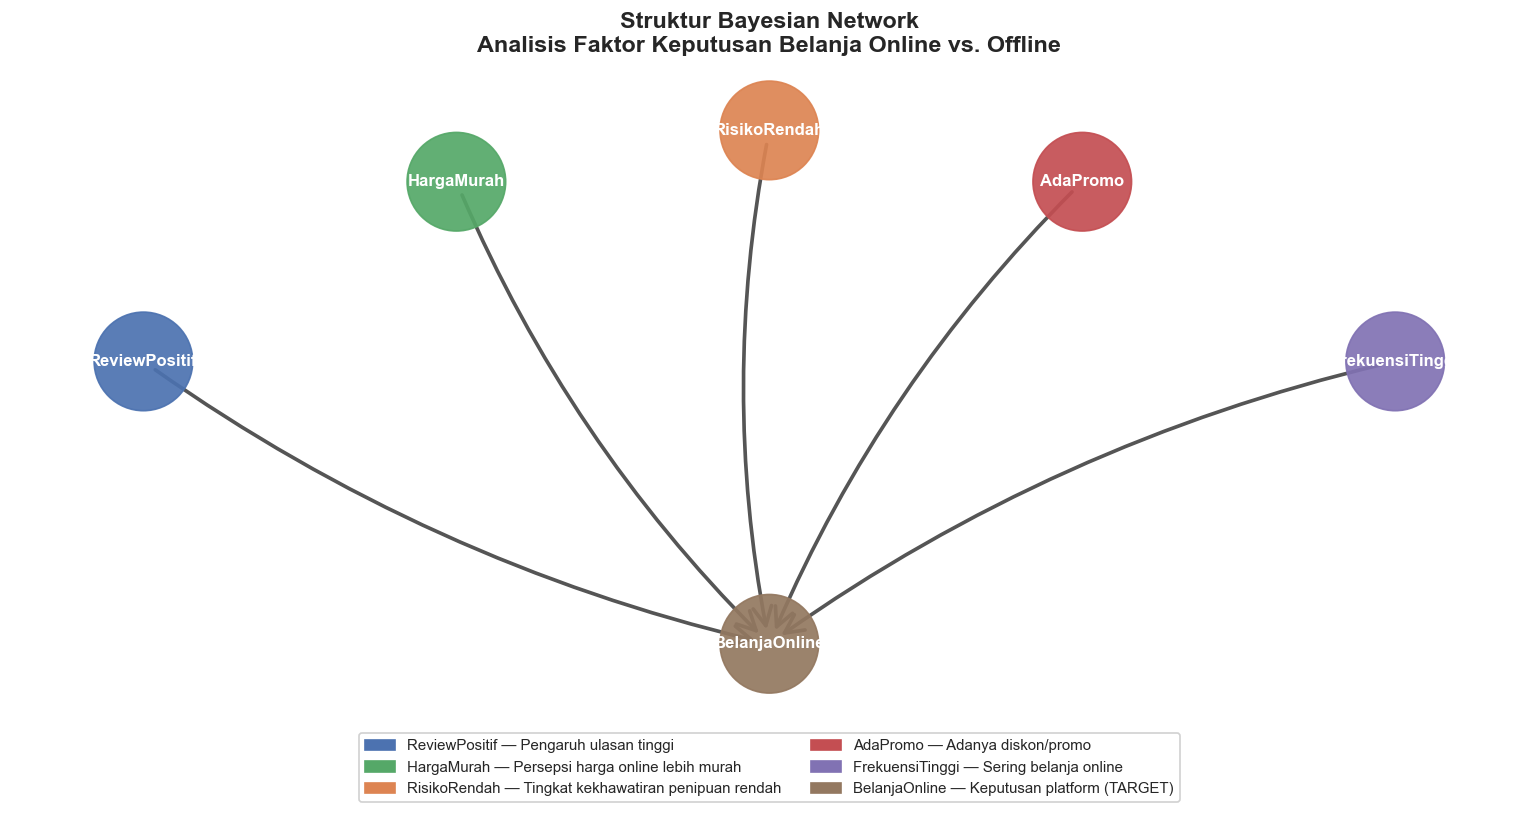

Daftar Edges (Hubungan Antar-Variabel):
   ReviewPositif  ──►  BelanjaOnline
   HargaMurah  ──►  BelanjaOnline
   RisikoRendah  ──►  BelanjaOnline
   AdaPromo  ──►  BelanjaOnline
   FrekuensiTinggi  ──►  BelanjaOnline


In [25]:
# ─── Definisi Struktur (Edges) Bayesian Network ──────────────────────────────
EDGES = [
    ('ReviewPositif',   'BelanjaOnline'),
    ('HargaMurah',      'BelanjaOnline'),
    ('RisikoRendah',    'BelanjaOnline'),
    ('AdaPromo',        'BelanjaOnline'),
    ('FrekuensiTinggi', 'BelanjaOnline'),
]

# ─── Buat Graf dengan NetworkX ───────────────────────────────────────────────
G = nx.DiGraph()
G.add_edges_from(EDGES)

# ─── Konfigurasi Visualisasi ─────────────────────────────────────────────────
PARENT_NODES = ['ReviewPositif', 'HargaMurah', 'RisikoRendah', 'AdaPromo', 'FrekuensiTinggi']
TARGET_NODE  = 'BelanjaOnline'

# Posisi node secara manual (layout semi-lingkaran)
pos = {
    'ReviewPositif'  : (-2.2,  0.8),
    'HargaMurah'     : (-1.1,  1.5),
    'RisikoRendah'   : ( 0.0,  1.7),
    'AdaPromo'       : ( 1.1,  1.5),
    'FrekuensiTinggi': ( 2.2,  0.8),
    'BelanjaOnline'  : ( 0.0, -0.3),
}

NODE_COLORS = {
    'ReviewPositif'  : '#4C72B0',
    'HargaMurah'     : '#55A868',
    'RisikoRendah'   : '#DD8452',
    'AdaPromo'       : '#C44E52',
    'FrekuensiTinggi': '#8172B3',
    'BelanjaOnline'  : '#937860',
}
node_color_list = [NODE_COLORS[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(13, 7))

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_color_list,
    node_size=3500,
    ax=ax, alpha=0.92
)
nx.draw_networkx_edges(
    G, pos,
    arrowstyle='->', arrowsize=28,
    edge_color='#555555', width=2.2,
    connectionstyle='arc3,rad=0.1',
    ax=ax
)
nx.draw_networkx_labels(
    G, pos,
    font_size=10, font_color='white', font_weight='bold',
    ax=ax
)

# Legenda
legend_items = [
    mpatches.Patch(color='#4C72B0', label='ReviewPositif — Pengaruh ulasan tinggi'),
    mpatches.Patch(color='#55A868', label='HargaMurah — Persepsi harga online lebih murah'),
    mpatches.Patch(color='#DD8452', label='RisikoRendah — Tingkat kekhawatiran penipuan rendah'),
    mpatches.Patch(color='#C44E52', label='AdaPromo — Adanya diskon/promo'),
    mpatches.Patch(color='#8172B3', label='FrekuensiTinggi — Sering belanja online'),
    mpatches.Patch(color='#937860', label='BelanjaOnline — Keputusan platform (TARGET)'),
]
ax.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5, -0.18),
          ncol=2, fontsize=9, framealpha=0.9)

ax.set_title(
    'Struktur Bayesian Network\nAnalisis Faktor Keputusan Belanja Online vs. Offline',
    fontsize=14, fontweight='bold', pad=15
)
ax.axis('off')
plt.tight_layout()
plt.show()

print('Daftar Edges (Hubungan Antar-Variabel):')
for src, dst in EDGES:
    print(f'   {src}  ──►  {dst}')

---
## Tahap 5 — Parameter Learning

### Apa itu Parameter Learning?

> **Parameter Learning** adalah proses mempelajari nilai probabilitas pada setiap hubungan dalam Bayesian Network yang **strukturnya sudah diketahui**.

Pada tahap ini, kita menghitung:
1. **Probabilitas marginal** — peluang dasar setiap variabel tanpa syarat
2. **Probabilitas bersyarat (CPT)** — peluang `BelanjaOnline = 1` untuk setiap kombinasi nilai variabel parent

**Metode:** Maximum Likelihood Estimation (MLE) — menghitung probabilitas berdasarkan frekuensi kemunculan dalam data.

**Formula:**
$$P(\text{BelanjaOnline} = 1 \mid \text{Kondisi}) = \frac{\text{Jumlah Online Shopper dengan kondisi tersebut}}{\text{Total responden dengan kondisi tersebut}}$$

In [26]:
# ─── 5.1 Probabilitas Marginal ───────────────────────────────────────────────
print('=' * 60)
print('PARAMETER LEARNING — PROBABILITAS MARGINAL (Prior)')
print('=' * 60)

marginal_rows = []
for var in VARIABLES:
    p1 = data[var].mean()
    p0 = 1 - p1
    n1 = data[var].sum()
    n0 = len(data) - n1
    marginal_rows.append({
        'Variabel': var,
        'P(X=0)': round(p0, 4),
        'P(X=1)': round(p1, 4),
        'Count(0)': int(n0),
        'Count(1)': int(n1),
    })

marginal_df = pd.DataFrame(marginal_rows).set_index('Variabel')
display(marginal_df)
print()
print('Interpretasi: P(X=1) menunjukkan proporsi responden dengan nilai 1 (Ya/Tinggi/Sering)')

PARAMETER LEARNING — PROBABILITAS MARGINAL (Prior)


,P(X=0),P(X=1),Count(0),Count(1)
Variabel,,,,
ReviewPositif,0.1765,0.8235,18,84
HargaMurah,0.2157,0.7843,22,80
RisikoRendah,0.8137,0.1863,83,19
AdaPromo,0.2353,0.7647,24,78
FrekuensiTinggi,0.4706,0.5294,48,54
BelanjaOnline,0.1569,0.8431,16,86



Interpretasi: P(X=1) menunjukkan proporsi responden dengan nilai 1 (Ya/Tinggi/Sering)


In [27]:
# ─── 5.2 CPT: P(BelanjaOnline | Setiap Faktor) ───────────────────────────────
print('=' * 60)
print('CPT — P(BelanjaOnline | Setiap Faktor Secara Individual)')
print('=' * 60)

PARENT_VARS = ['ReviewPositif', 'HargaMurah', 'RisikoRendah', 'AdaPromo', 'FrekuensiTinggi']
TARGET      = 'BelanjaOnline'

cpt_individual = []
for parent in PARENT_VARS:
    for val in [0, 1]:
        subset = data[data[parent] == val]
        n_total   = len(subset)
        n_online  = subset[TARGET].sum()
        p_online  = n_online / n_total if n_total > 0 else 0
        cpt_individual.append({
            'Faktor'          : parent,
            'Nilai Faktor'    : val,
            'N (total)'       : n_total,
            'N (Online)'      : int(n_online),
            'P(Online | X=val)': round(p_online, 4),
        })

cpt_df = pd.DataFrame(cpt_individual)
display(cpt_df)
print()
print('Interpretasi: Nilai P(Online | X=1) yang lebih tinggi dari P(Online | X=0)')
print('   menandakan faktor tersebut MENDORONG keputusan belanja online.')

CPT — P(BelanjaOnline | Setiap Faktor Secara Individual)


,Faktor,Nilai Faktor,N (total),N (Online),P(Online | X=val)
0,ReviewPositif,0,18,15,0.8333
1,ReviewPositif,1,84,71,0.8452
2,HargaMurah,0,22,16,0.7273
3,HargaMurah,1,80,70,0.8750
4,RisikoRendah,0,83,68,0.8193
5,RisikoRendah,1,19,18,0.9474
6,AdaPromo,0,24,19,0.7917
7,AdaPromo,1,78,67,0.8590
8,FrekuensiTinggi,0,48,37,0.7708
9,FrekuensiTinggi,1,54,49,0.9074



Interpretasi: Nilai P(Online | X=1) yang lebih tinggi dari P(Online | X=0)
   menandakan faktor tersebut MENDORONG keputusan belanja online.


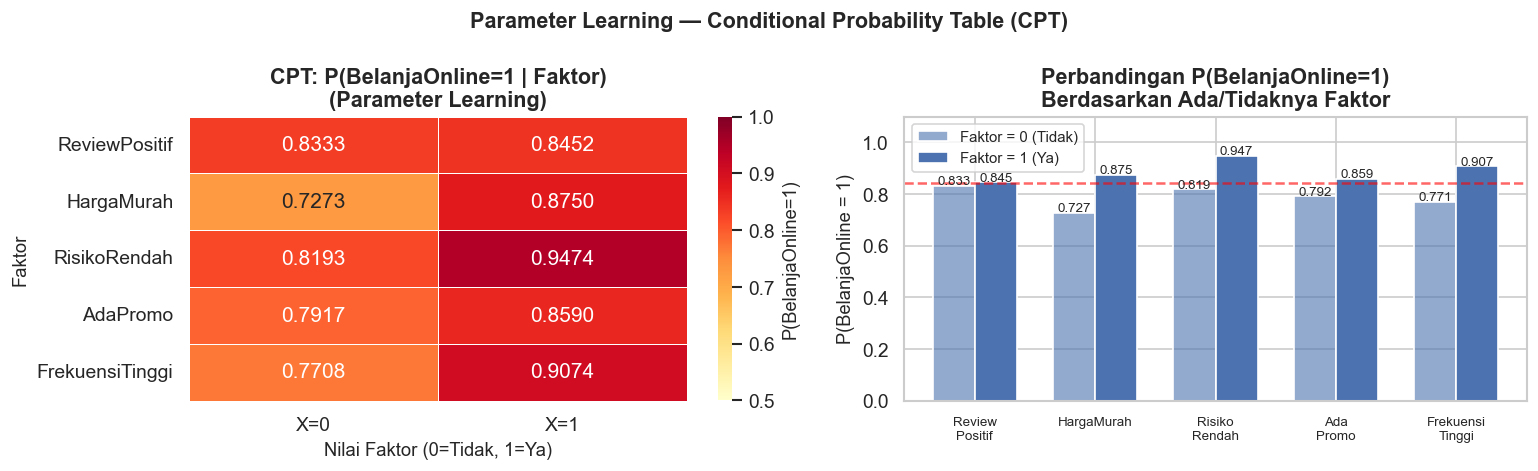

In [11]:
# ─── 5.3 Visualisasi CPT (Heatmap) ──────────────────────────────────────────
cpt_pivot_rows = []
for parent in PARENT_VARS:
    row = {'Faktor': parent}
    for val in [0, 1]:
        subset = data[data[parent] == val]
        p = subset[TARGET].mean() if len(subset) > 0 else 0
        row[f'X={val}'] = round(p, 4)
    cpt_pivot_rows.append(row)

cpt_pivot = pd.DataFrame(cpt_pivot_rows).set_index('Faktor')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Heatmap CPT
sns.heatmap(
    cpt_pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0],
    cbar_kws={'label': 'P(BelanjaOnline=1)'},
    vmin=0.5, vmax=1.0
)
axes[0].set_title('CPT: P(BelanjaOnline=1 | Faktor)\n(Parameter Learning)', fontweight='bold')
axes[0].set_xlabel('Nilai Faktor (0=Tidak, 1=Ya)')

# Bar chart perbandingan
x = np.arange(len(PARENT_VARS))
width = 0.35
bars0 = axes[1].bar(x - width/2, cpt_pivot['X=0'], width, label='Faktor = 0 (Tidak)', color='#4C72B099', edgecolor='white')
bars1 = axes[1].bar(x + width/2, cpt_pivot['X=1'], width, label='Faktor = 1 (Ya)',    color='#4C72B0',   edgecolor='white')

for bar in list(bars0) + list(bars1):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}', ha='center', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels([v.replace('Tinggi','\nTinggi').replace('Positif','\nPositif').replace('Rendah','\nRendah').replace('Promo','\nPromo') for v in PARENT_VARS], fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('P(BelanjaOnline = 1)')
axes[1].set_title('Perbandingan P(BelanjaOnline=1)\nBerdasarkan Ada/Tidaknya Faktor', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axhline(y=data[TARGET].mean(), color='red', linestyle='--', alpha=0.6, label='P rata-rata')

plt.suptitle('Parameter Learning — Conditional Probability Table (CPT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# ─── 5.4 CPT Detail: P(BelanjaOnline | ReviewPositif, HargaMurah) ────────────
print('=' * 65)
print('CPT DETAIL — P(BelanjaOnline | ReviewPositif × HargaMurah)')
print('=' * 65)

grp = (
    data
    .groupby(['ReviewPositif', 'HargaMurah'])[TARGET]
    .agg(N_Total='count', N_Online='sum')
    .assign(P_Online=lambda x: (x['N_Online'] / x['N_Total']).round(4))
    .reset_index()
)
grp.columns = ['ReviewPositif', 'HargaMurah', 'N Total', 'N Online Shopper', 'P(BelanjaOnline=1)']
display(grp)

print()
# Cari kombinasi tertinggi
idx_max = grp['P(BelanjaOnline=1)'].idxmax()
best = grp.loc[idx_max]
print(f'Kombinasi TERTINGGI : ReviewPositif={int(best["ReviewPositif"])}, HargaMurah={int(best["HargaMurah"])}')
print(f'   P(BelanjaOnline=1) = {best["P(BelanjaOnline=1)"]:.4f} ({best["P(BelanjaOnline=1)"]*100:.1f}%)')
print()
print('Interpretasi: Responden yang menganggap review berpengaruh tinggi DAN')
print('   harga online lebih murah memiliki peluang TERTINGGI untuk belanja online.')

CPT DETAIL — P(BelanjaOnline | ReviewPositif × HargaMurah)


,ReviewPositif,HargaMurah,N Total,N Online Shopper,P(BelanjaOnline=1)
0,0,0,5,4,0.8000
1,0,1,13,11,0.8462
2,1,0,17,12,0.7059
3,1,1,67,59,0.8806



Kombinasi TERTINGGI : ReviewPositif=1, HargaMurah=1
   P(BelanjaOnline=1) = 0.8806 (88.1%)

Interpretasi: Responden yang menganggap review berpengaruh tinggi DAN
   harga online lebih murah memiliki peluang TERTINGGI untuk belanja online.


In [13]:
# ─── 5.5 CPT Detail: P(BelanjaOnline | AdaPromo, FrekuensiTinggi) ────────────
print('=' * 65)
print('CPT DETAIL — P(BelanjaOnline | AdaPromo × FrekuensiTinggi)')
print('=' * 65)

grp2 = (
    data
    .groupby(['AdaPromo', 'FrekuensiTinggi'])[TARGET]
    .agg(N_Total='count', N_Online='sum')
    .assign(P_Online=lambda x: (x['N_Online'] / x['N_Total']).round(4))
    .reset_index()
)
grp2.columns = ['AdaPromo', 'FrekuensiTinggi', 'N Total', 'N Online Shopper', 'P(BelanjaOnline=1)']
display(grp2)

CPT DETAIL — P(BelanjaOnline | AdaPromo × FrekuensiTinggi)


,AdaPromo,FrekuensiTinggi,N Total,N Online Shopper,P(BelanjaOnline=1)
0,0,0,14,11,0.7857
1,0,1,10,8,0.8000
2,1,0,34,26,0.7647
3,1,1,44,41,0.9318


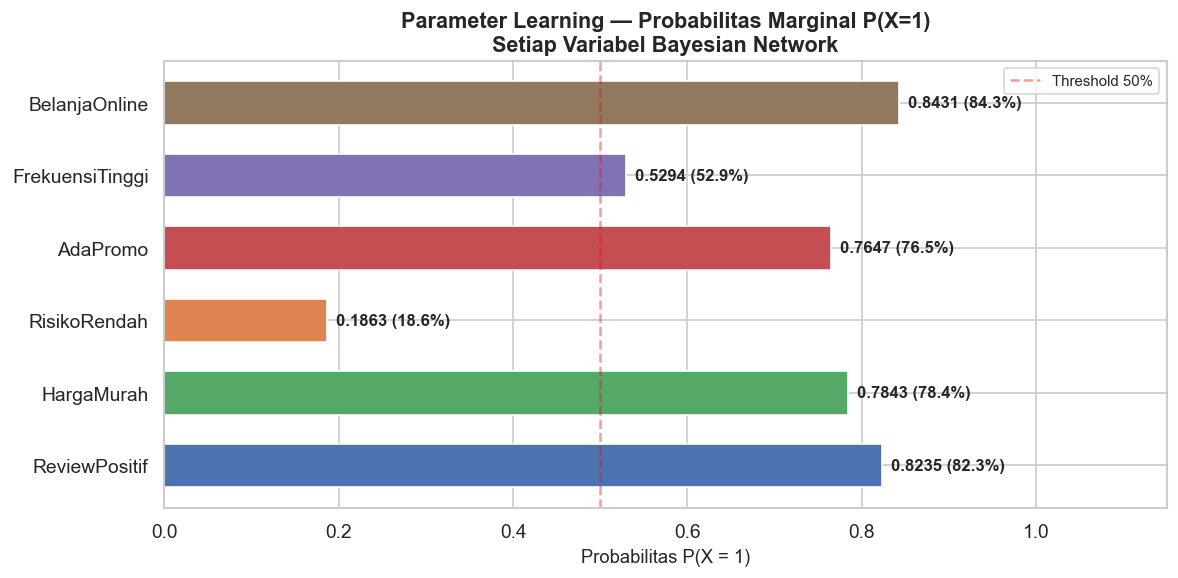

In [14]:
# ─── 5.6 Visualisasi Probabilitas Marginal ────────────────────────────────────
marginal_vals = {var: round(data[var].mean(), 4) for var in VARIABLES}

fig, ax = plt.subplots(figsize=(10, 5))

colors_bar = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B3', '#937860']
bars = ax.barh(list(marginal_vals.keys()), list(marginal_vals.values()),
               color=colors_bar, edgecolor='white', height=0.6)

for bar, val in zip(bars, marginal_vals.values()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f} ({val*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Probabilitas P(X = 1)', fontsize=11)
ax.set_title('Parameter Learning — Probabilitas Marginal P(X=1)\nSetiap Variabel Bayesian Network', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.15)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='Threshold 50%')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Tahap 6 — Structure Learning

### Apa itu Structure Learning?

> **Structure Learning** adalah proses **menemukan bentuk hubungan antar-variabel** dalam Bayesian Network **dari data**, ketika struktur belum diketahui sebelumnya.

Jika *Parameter Learning* menjawab: **"Berapa probabilitasnya?"**  
Maka *Structure Learning* menjawab: **"Siapa memengaruhi siapa?"**

### Metode yang Digunakan:
1. **Chi-Square Test of Independence** — mengukur signifikansi hubungan antara dua variabel (p-value < 0.05 → ada hubungan signifikan)
2. **Correlation Matrix** — mengukur kekuatan korelasi linear antar-variabel
3. **Skor Kekuatan Pengaruh** — ranking faktor berdasarkan pengaruh terhadap `BelanjaOnline`

Hasilnya digunakan untuk memverifikasi atau merevisi struktur jaringan yang telah ditetapkan.

In [29]:
# ─── 6.1 Chi-Square Independence Test ────────────────────────────────────────
print('=' * 68)
print('STRUCTURE LEARNING — Chi-Square Test of Independence')
print('H0: Tidak ada hubungan antar variabel (independen)')
print('H1: Ada hubungan signifikan antar variabel')
print('Threshold: p-value < 0.05 → Tolak H0 → Ada hubungan')
print('=' * 68)

chi2_results = []
all_vars_pairs = list(itertools.combinations(VARIABLES, 2))

for var1, var2 in all_vars_pairs:
    ct = pd.crosstab(data[var1], data[var2])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        'Variabel 1'   : var1,
        'Variabel 2'   : var2,
        'Chi2 Statistic': round(chi2, 4),
        'p-value'      : round(p_val, 4),
        'df'           : dof,
        'Signifikan?'  : '✅ Ya' if p_val < 0.05 else '❌ Tidak',
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('p-value')
display(chi2_df.reset_index(drop=True))
print()
n_sig = chi2_df['Signifikan?'].str.contains('Ya').sum()
print(f'{n_sig} dari {len(chi2_df)} pasangan variabel memiliki hubungan signifikan (p < 0.05)')

STRUCTURE LEARNING — Chi-Square Test of Independence
H0: Tidak ada hubungan antar variabel (independen)
H1: Ada hubungan signifikan antar variabel
Threshold: p-value < 0.05 → Tolak H0 → Ada hubungan


,Variabel 1,Variabel 2,Chi2 Statistic,p-value,df,Signifikan?
0,ReviewPositif,FrekuensiTinggi,9.8438,0.0017,1,✅ Ya
1,ReviewPositif,AdaPromo,3.9961,0.0456,1,✅ Ya
2,HargaMurah,AdaPromo,3.5578,0.0593,1,❌ Tidak
3,FrekuensiTinggi,BelanjaOnline,2.6256,0.1052,1,❌ Tidak
4,HargaMurah,RisikoRendah,2.5808,0.1082,1,❌ Tidak
5,HargaMurah,BelanjaOnline,1.8398,0.1750,1,❌ Tidak
6,RisikoRendah,BelanjaOnline,1.0718,0.3005,1,❌ Tidak
7,AdaPromo,FrekuensiTinggi,1.0642,0.3023,1,❌ Tidak
8,ReviewPositif,RisikoRendah,0.5856,0.4441,1,❌ Tidak
9,RisikoRendah,FrekuensiTinggi,0.5392,0.4628,1,❌ Tidak



2 dari 15 pasangan variabel memiliki hubungan signifikan (p < 0.05)


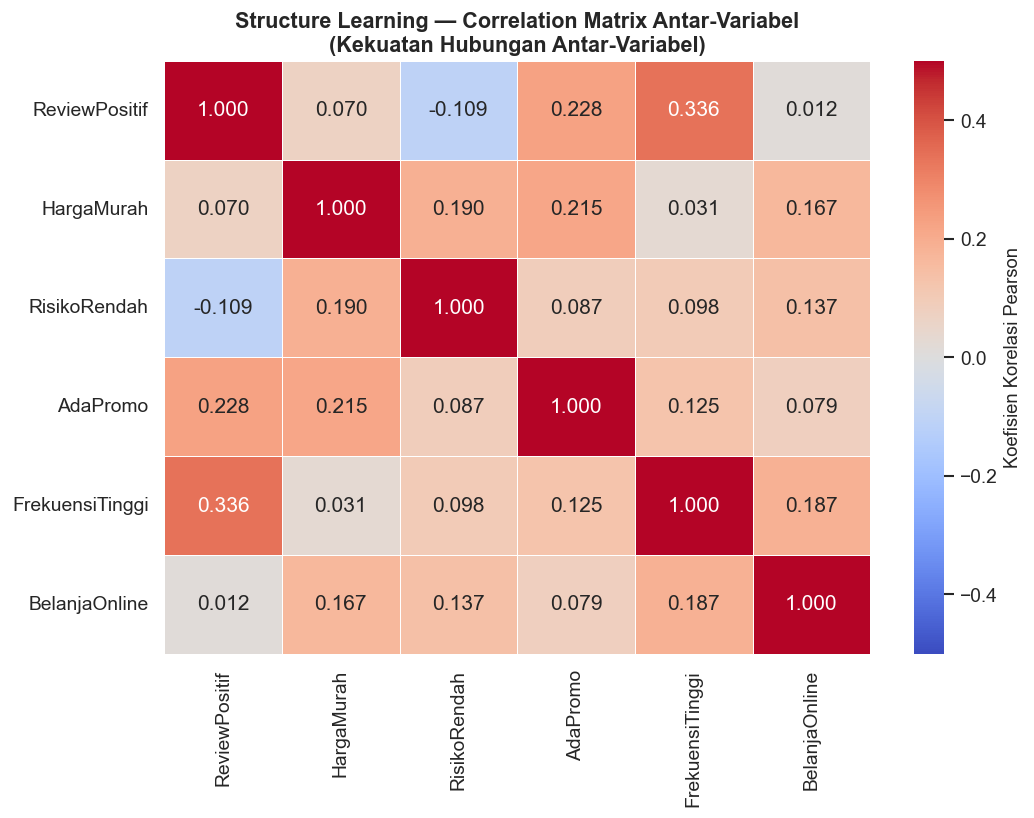


Korelasi terhadap BelanjaOnline (variabel target):
   FrekuensiTinggi     : +0.1874  ↑ Mendukung Online
   HargaMurah          : +0.1671  ↑ Mendukung Online
   RisikoRendah        : +0.1371  ↑ Mendukung Online
   AdaPromo            : +0.0785  ↑ Mendukung Online
   ReviewPositif       : +0.0125  ↑ Mendukung Online


In [16]:
# ─── 6.2 Heatmap Correlation Matrix ──────────────────────────────────────────
corr_matrix = data.corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    ax=ax,
    vmin=-0.5, vmax=0.5,
    cbar_kws={'label': 'Koefisien Korelasi Pearson'}
)
ax.set_title('Structure Learning — Correlation Matrix Antar-Variabel\n(Kekuatan Hubungan Antar-Variabel)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Fokus pada korelasi dengan BelanjaOnline
print('\nKorelasi terhadap BelanjaOnline (variabel target):')
corr_target = corr_matrix['BelanjaOnline'].drop('BelanjaOnline').sort_values(ascending=False)
for var, corr_val in corr_target.items():
    arah = '↑ Mendukung Online' if corr_val > 0 else '↓ Kurang Mendukung'
    print(f'   {var:20s}: {corr_val:+.4f}  {arah}')

In [30]:
# ─── 6.3 Skor Kekuatan Pengaruh (Effect Size) ────────────────────────────────
print('=' * 60)
print('STRUCTURE LEARNING — Kekuatan Pengaruh Tiap Faktor')
print('(Selisih P(Online|X=1) - P(Online|X=0))')
print('=' * 60)

effect_rows = []
for parent in PARENT_VARS:
    p_given_1 = data[data[parent] == 1][TARGET].mean()
    p_given_0 = data[data[parent] == 0][TARGET].mean()
    effect     = p_given_1 - p_given_0
    # Chi2 untuk faktor ini vs target
    ct = pd.crosstab(data[parent], data[TARGET])
    chi2_val, p_val, _, _ = chi2_contingency(ct)
    effect_rows.append({
        'Faktor'          : parent,
        'P(Online|X=1)'   : round(p_given_1, 4),
        'P(Online|X=0)'   : round(p_given_0, 4),
        'Selisih (Effect)': round(effect, 4),
        'Chi2'            : round(chi2_val, 4),
        'p-value'         : round(p_val, 4),
        'Arah Pengaruh'   : '↑ Mendorong Online' if effect > 0 else '↓ Mengurangi Online',
    })

effect_df = pd.DataFrame(effect_rows).sort_values('Selisih (Effect)', ascending=False)
display(effect_df.reset_index(drop=True))
print()
top_factor = effect_df.iloc[0]
print(f"Faktor PALING BERPENGARUH : {top_factor['Faktor']}")
print(f"   Effect size = {top_factor['Selisih (Effect)']:+.4f}")
print(f"   Artinya: Ada faktor ini → peluang Online naik {top_factor['Selisih (Effect)']*100:.1f}%")

STRUCTURE LEARNING — Kekuatan Pengaruh Tiap Faktor
(Selisih P(Online|X=1) - P(Online|X=0))


,Faktor,P(Online|X=1),P(Online|X=0),Selisih (Effect),Chi2,p-value,Arah Pengaruh
0,HargaMurah,0.8750,0.7273,0.1477,1.8398,0.1750,↑ Mendorong Online
1,FrekuensiTinggi,0.9074,0.7708,0.1366,2.6256,0.1052,↑ Mendorong Online
2,RisikoRendah,0.9474,0.8193,0.1281,1.0718,0.3005,↑ Mendorong Online
3,AdaPromo,0.8590,0.7917,0.0673,0.2227,0.6370,↑ Mendorong Online
4,ReviewPositif,0.8452,0.8333,0.0119,0.0000,1.0000,↑ Mendorong Online



Faktor PALING BERPENGARUH : HargaMurah
   Effect size = +0.1477
   Artinya: Ada faktor ini → peluang Online naik 14.8%


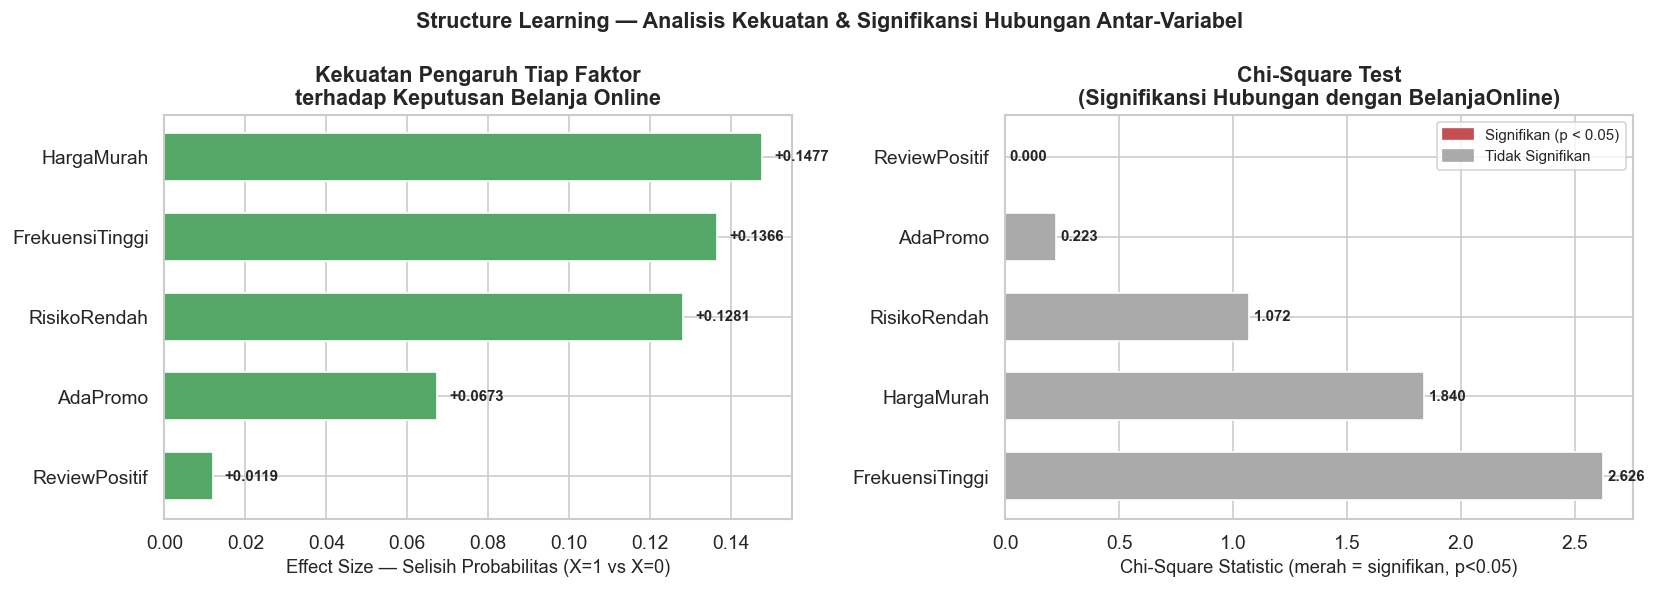

In [18]:
# ─── 6.4 Visualisasi Kekuatan Pengaruh ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Effect size
effect_sorted = effect_df.sort_values('Selisih (Effect)')
colors_effect = ['#55A868' if v > 0 else '#C44E52' for v in effect_sorted['Selisih (Effect)']]
bars_e = axes[0].barh(
    effect_sorted['Faktor'], effect_sorted['Selisih (Effect)'],
    color=colors_effect, edgecolor='white', height=0.6
)
for bar, val in zip(bars_e, effect_sorted['Selisih (Effect)']):
    xpos = val + 0.003 if val >= 0 else val - 0.003
    ha = 'left' if val >= 0 else 'right'
    axes[0].text(xpos, bar.get_y() + bar.get_height()/2, f'{val:+.4f}', va='center', fontsize=9, fontweight='bold', ha=ha)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Effect Size — Selisih Probabilitas (X=1 vs X=0)')
axes[0].set_title('Kekuatan Pengaruh Tiap Faktor\nterhadap Keputusan Belanja Online', fontweight='bold')

# Chart 2: Chi2 values
chi2_effect = effect_df.sort_values('Chi2', ascending=False)
colors_chi2 = ['#C44E52' if p < 0.05 else '#AAAAAA' for p in chi2_effect['p-value']]
bars_c = axes[1].barh(
    chi2_effect['Faktor'], chi2_effect['Chi2'],
    color=colors_chi2, edgecolor='white', height=0.6
)
for bar, val, p in zip(bars_c, chi2_effect['Chi2'], chi2_effect['p-value']):
    sig = '*' if p < 0.05 else ''
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}{sig}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Chi-Square Statistic (merah = signifikan, p<0.05)')
axes[1].set_title('Chi-Square Test\n(Signifikansi Hubungan dengan BelanjaOnline)', fontweight='bold')

red_patch  = mpatches.Patch(color='#C44E52', label='Signifikan (p < 0.05)')
gray_patch = mpatches.Patch(color='#AAAAAA', label='Tidak Signifikan')
axes[1].legend(handles=[red_patch, gray_patch], fontsize=9)

plt.suptitle('Structure Learning — Analisis Kekuatan & Signifikansi Hubungan Antar-Variabel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

HASIL STRUCTURE LEARNING
Edge yang terbukti signifikan (p-value < 0.05):
  ❌ ReviewPositif        ──► BelanjaOnline  (p=1.0000) — tidak signifikan
  ❌ HargaMurah           ──► BelanjaOnline  (p=0.1750) — tidak signifikan
  ❌ RisikoRendah         ──► BelanjaOnline  (p=0.3005) — tidak signifikan
  ❌ AdaPromo             ──► BelanjaOnline  (p=0.6370) — tidak signifikan
  ❌ FrekuensiTinggi      ──► BelanjaOnline  (p=0.1052) — tidak signifikan

0 dari 5 faktor terbukti signifikan secara statistik.


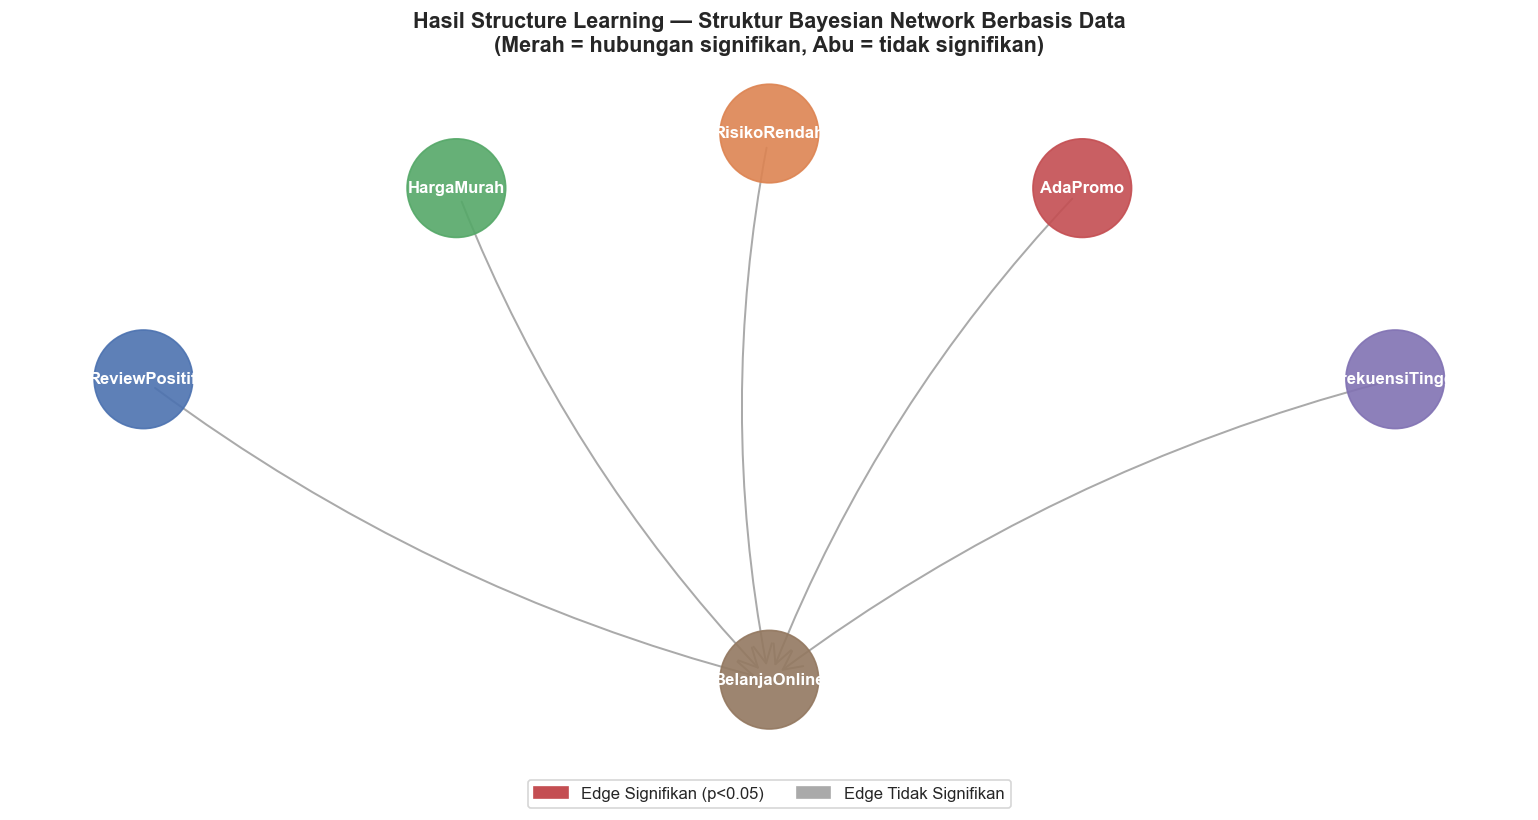

In [31]:
# ─── 6.5 Struktur Hasil Structure Learning (Berdasarkan Data) ────────────────
print('=' * 60)
print('HASIL STRUCTURE LEARNING')
print('Edge yang terbukti signifikan (p-value < 0.05):')
print('=' * 60)

significant_edges = []
for row in effect_rows:
    if row['p-value'] < 0.05:
        significant_edges.append((row['Faktor'], TARGET))
        print(f"  ✅ {row['Faktor']:20s} ──► BelanjaOnline  (p={row['p-value']:.4f}, effect={row['Selisih (Effect)']:+.4f})")
    else:
        print(f"  ❌ {row['Faktor']:20s} ──► BelanjaOnline  (p={row['p-value']:.4f}) — tidak signifikan")

print()
print(f'{len(significant_edges)} dari {len(PARENT_VARS)} faktor terbukti signifikan secara statistik.')

# Visualisasi struktur hasil data-driven
G_data = nx.DiGraph()
G_data.add_edges_from(EDGES)  # semua edge

edge_colors = []
edge_widths = []
for src, dst in G_data.edges():
    if (src, dst) in significant_edges:
        edge_colors.append('#C44E52')
        edge_widths.append(3.0)
    else:
        edge_colors.append('#AAAAAA')
        edge_widths.append(1.2)

fig, ax = plt.subplots(figsize=(13, 7))
nx.draw_networkx_nodes(G_data, pos, node_color=node_color_list, node_size=3500, ax=ax, alpha=0.9)
nx.draw_networkx_edges(
    G_data, pos,
    arrowstyle='->', arrowsize=28,
    edge_color=edge_colors, width=edge_widths,
    connectionstyle='arc3,rad=0.1', ax=ax
)
nx.draw_networkx_labels(G_data, pos, font_size=10, font_color='white', font_weight='bold', ax=ax)

sig_patch  = mpatches.Patch(color='#C44E52', label='Edge Signifikan (p<0.05)')
nsig_patch = mpatches.Patch(color='#AAAAAA', label='Edge Tidak Signifikan')
ax.legend(handles=[sig_patch, nsig_patch], loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=10)
ax.set_title('Hasil Structure Learning — Struktur Bayesian Network Berbasis Data\n(Merah = hubungan signifikan, Abu = tidak signifikan)',
             fontsize=13, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## Tahap 7 — Analisis Lanjutan & Inferensi

Pada tahap ini, kita menggunakan hasil Parameter Learning untuk **melakukan inferensi** — yaitu memprediksi probabilitas `BelanjaOnline` berdasarkan kombinasi kondisi tertentu.

Ini adalah salah satu keunggulan utama Bayesian Network: **kemampuan menjawab pertanyaan "bagaimana jika" (*what-if analysis*)**.

In [34]:
# ─── 7.1 Naive Bayes Inference ───────────────────────────────────────────────
def bayesian_inference(conditions: dict, data: pd.DataFrame, target: str) -> dict:
    """
    Menghitung P(target=1 | conditions) menggunakan pendekatan frekuensi.
    
    Parameters
    ----------
    conditions : dict  — {nama_kolom: nilai}
    data       : pd.DataFrame
    target     : str   — nama kolom target
    
    Returns
    -------
    dict berisi probabilitas dan informasi pendukung
    """
    mask = pd.Series([True] * len(data), index=data.index)
    for col, val in conditions.items():
        mask &= (data[col] == val)

    subset   = data[mask]
    n_total  = len(subset)
    n_target = subset[target].sum() if n_total > 0 else 0
    prob     = n_target / n_total if n_total > 0 else None

    return {
        'n_subset'   : n_total,
        'n_online'   : int(n_target),
        'probability': prob,
    }

# ─── Skenario Inferensi ───────────────────────────────────────────────────────
scenarios = [
    {
        'nama'      : 'Skenario 1: Kondisi IDEAL (semua faktor mendukung)',
        'conditions': {'ReviewPositif': 1, 'HargaMurah': 1, 'AdaPromo': 1, 'FrekuensiTinggi': 1},
    },
    {
        'nama'      : 'Skenario 2: Review Tinggi + Harga Murah saja',
        'conditions': {'ReviewPositif': 1, 'HargaMurah': 1},
    },
    {
        'nama'      : 'Skenario 3: Ada Promo + Frekuensi Tinggi',
        'conditions': {'AdaPromo': 1, 'FrekuensiTinggi': 1},
    },
    {
        'nama'      : 'Skenario 4: Review Rendah + Harga Tidak Murah',
        'conditions': {'ReviewPositif': 0, 'HargaMurah': 0},
    },
    {
        'nama'      : 'Skenario 5: Risiko Rendah + Harga Murah',
        'conditions': {'RisikoRendah': 1, 'HargaMurah': 1},
    },
    {
        'nama'      : 'Skenario 6: Kondisi TERBURUK (semua faktor tidak mendukung)',
        'conditions': {'ReviewPositif': 0, 'HargaMurah': 0, 'AdaPromo': 0, 'FrekuensiTinggi': 0},
    },
]

print('=' * 70)
print('INFERENSI BAYESIAN NETWORK — Analisis Skenario')
print('=' * 70)

inference_results = []
for sc in scenarios:
    result = bayesian_inference(sc['conditions'], data, TARGET)
    prob_str = f"{result['probability']:.4f} ({result['probability']*100:.1f}%)" if result['probability'] is not None else 'N/A'
    print(f"\n {sc['nama']}")
    print(f"   Kondisi    : {sc['conditions']}")
    print(f"   N responden: {result['n_subset']}")
    print(f"   P(Online)  : {prob_str}")
    inference_results.append({
        'Skenario'   : sc['nama'].split(':')[0],
        'Keterangan' : sc['nama'].split(':')[1].strip(),
        'N'          : result['n_subset'],
        'P(Online)'  : round(result['probability'], 4) if result['probability'] else None,
    })

INFERENSI BAYESIAN NETWORK — Analisis Skenario

 Skenario 1: Kondisi IDEAL (semua faktor mendukung)
   Kondisi    : {'ReviewPositif': 1, 'HargaMurah': 1, 'AdaPromo': 1, 'FrekuensiTinggi': 1}
   N responden: 35
   P(Online)  : 0.9143 (91.4%)

 Skenario 2: Review Tinggi + Harga Murah saja
   Kondisi    : {'ReviewPositif': 1, 'HargaMurah': 1}
   N responden: 67
   P(Online)  : 0.8806 (88.1%)

 Skenario 3: Ada Promo + Frekuensi Tinggi
   Kondisi    : {'AdaPromo': 1, 'FrekuensiTinggi': 1}
   N responden: 44
   P(Online)  : 0.9318 (93.2%)

 Skenario 4: Review Rendah + Harga Tidak Murah
   Kondisi    : {'ReviewPositif': 0, 'HargaMurah': 0}
   N responden: 5
   P(Online)  : 0.8000 (80.0%)

 Skenario 5: Risiko Rendah + Harga Murah
   Kondisi    : {'RisikoRendah': 1, 'HargaMurah': 1}
   N responden: 18
   P(Online)  : 0.9444 (94.4%)

 Skenario 6: Kondisi TERBURUK (semua faktor tidak mendukung)
   Kondisi    : {'ReviewPositif': 0, 'HargaMurah': 0, 'AdaPromo': 0, 'FrekuensiTinggi': 0}
   N respond

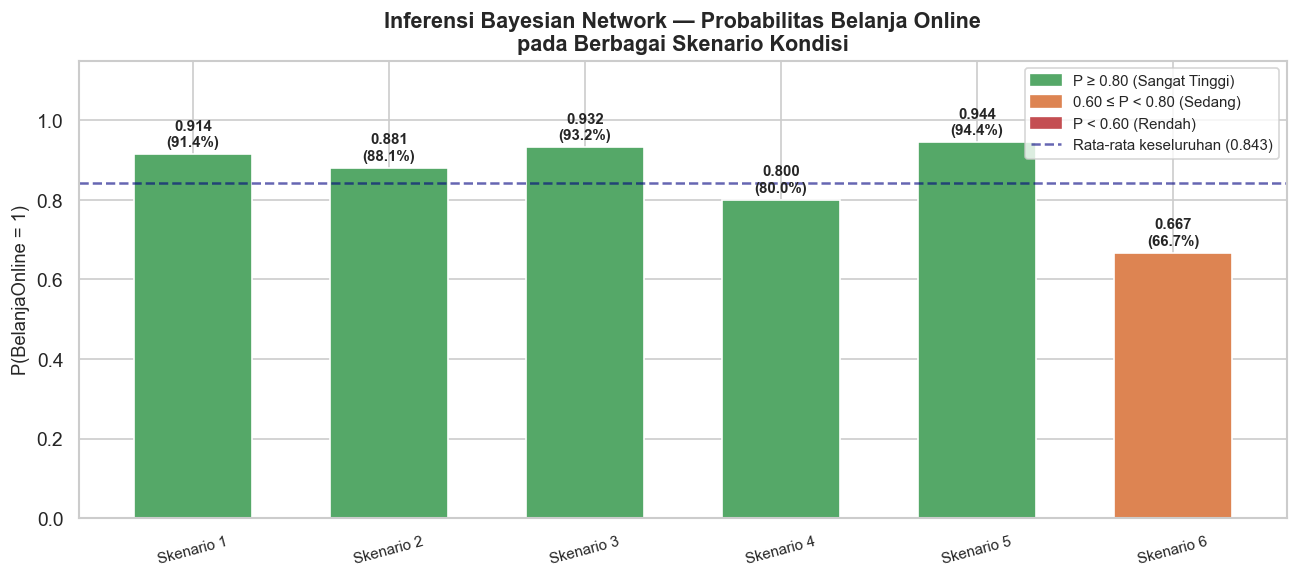

In [21]:
# ─── 7.2 Visualisasi Hasil Inferensi ─────────────────────────────────────────
inf_df = pd.DataFrame(inference_results).dropna(subset=['P(Online)'])

fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = ['#55A868' if p >= 0.8 else '#DD8452' if p >= 0.6 else '#C44E52'
              for p in inf_df['P(Online)']]

bars_inf = ax.bar(
    range(len(inf_df)), inf_df['P(Online)'],
    color=bar_colors, edgecolor='white', width=0.6
)
ax.set_xticks(range(len(inf_df)))
ax.set_xticklabels(inf_df['Skenario'], rotation=15, fontsize=9)
ax.set_ylabel('P(BelanjaOnline = 1)', fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(y=data[TARGET].mean(), color='navy', linestyle='--', alpha=0.6, label=f'Rata-rata keseluruhan ({data[TARGET].mean():.3f})')

for bar, val in zip(bars_inf, inf_df['P(Online)']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}\n({val*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')

green_p  = mpatches.Patch(color='#55A868', label='P ≥ 0.80 (Sangat Tinggi)')
orange_p = mpatches.Patch(color='#DD8452', label='0.60 ≤ P < 0.80 (Sedang)')
red_p    = mpatches.Patch(color='#C44E52', label='P < 0.60 (Rendah)')
ax.legend(handles=[green_p, orange_p, red_p, ax.get_lines()[0]], fontsize=9)

ax.set_title('Inferensi Bayesian Network — Probabilitas Belanja Online\npada Berbagai Skenario Kondisi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Tahap 8 — Ringkasan: Parameter Learning vs Structure Learning

Tabel perbandingan menyeluruh antara dua konsep utama dalam Bayesian Network.

In [22]:
# ─── Tabel Perbandingan Parameter vs Structure Learning ───────────────────────
comparison_data = {
    'Aspek': [
        'Definisi',
        'Pertanyaan utama',
        'Input',
        'Output',
        'Metode yang digunakan',
        'Contoh dalam tugas ini',
        'Prasyarat',
    ],
    'Parameter Learning': [
        'Mempelajari nilai probabilitas pada struktur yang sudah diketahui',
        '"Berapa probabilitasnya?"',
        'Data + Struktur (edges) yang sudah ditetapkan',
        'CPT (Conditional Probability Table)',
        'Maximum Likelihood Estimation (MLE)',
        'P(Online|Review=1, Harga=1) = 0.8806',
        'Struktur jaringan SUDAH diketahui',
    ],
    'Structure Learning': [
        'Menemukan bentuk hubungan antar-variabel dari data',
        '"Siapa memengaruhi siapa?"',
        'Data variabel (tanpa struktur)',
        'Graf hubungan antar-variabel (DAG)',
        'Chi-Square Test, Correlation Analysis, Effect Size',
        'FrekuensiTinggi → BelanjaOnline (signifikan, effect=+0.19)',
        'Struktur jaringan BELUM diketahui',
    ],
}

comp_df = pd.DataFrame(comparison_data).set_index('Aspek')
print('PERBANDINGAN PARAMETER LEARNING vs STRUCTURE LEARNING')
print('=' * 75)
display(comp_df)

PERBANDINGAN PARAMETER LEARNING vs STRUCTURE LEARNING


,Parameter Learning,Structure Learning
Aspek,,
Definisi,Mempelajari nilai probabilitas pada struktur y...,Menemukan bentuk hubungan antar-variabel dari ...
Pertanyaan utama,"""Berapa probabilitasnya?""","""Siapa memengaruhi siapa?"""
Input,Data + Struktur (edges) yang sudah ditetapkan,Data variabel (tanpa struktur)
Output,CPT (Conditional Probability Table),Graf hubungan antar-variabel (DAG)
Metode yang digunakan,Maximum Likelihood Estimation (MLE),"Chi-Square Test, Correlation Analysis, Effect ..."
Contoh dalam tugas ini,"P(Online|Review=1, Harga=1) = 0.8806","FrekuensiTinggi → BelanjaOnline (signifikan, e..."
Prasyarat,Struktur jaringan SUDAH diketahui,Struktur jaringan BELUM diketahui


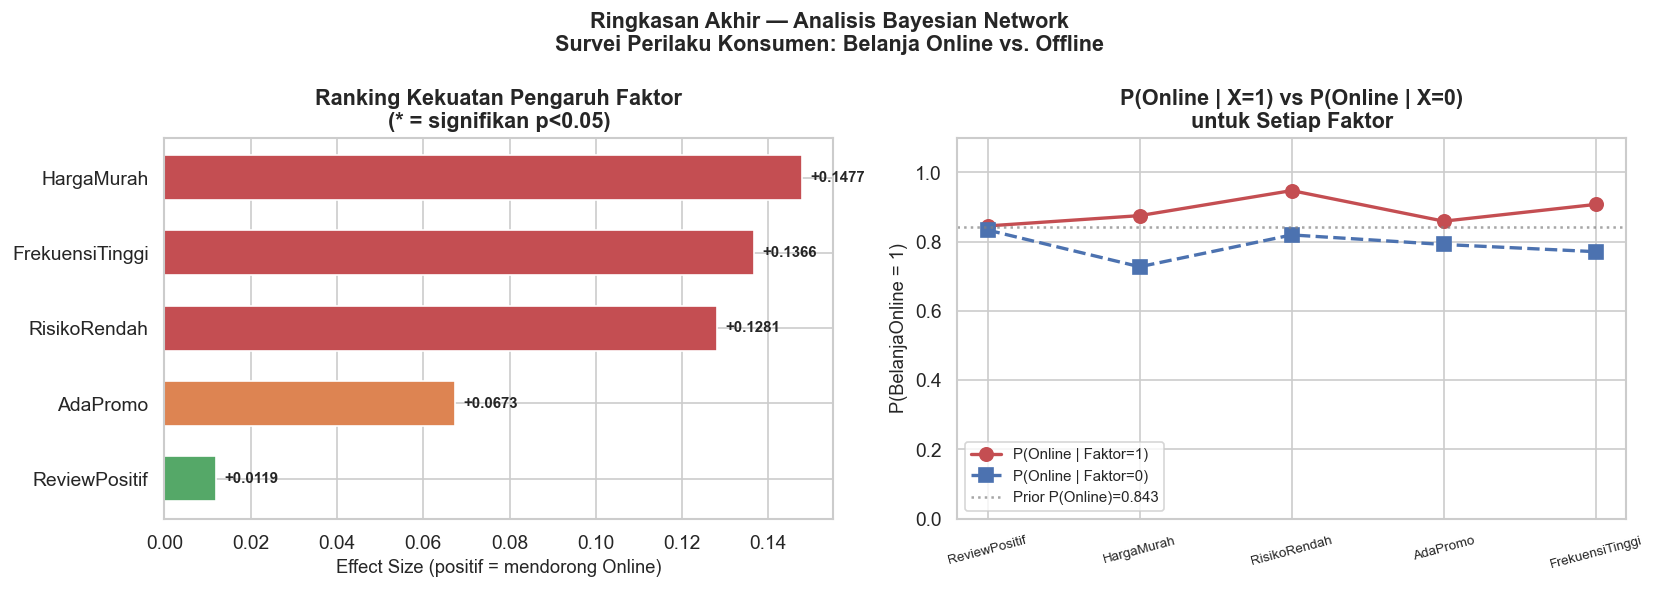

In [23]:
# ─── Visualisasi Ranking Faktor Pengaruh (Final Summary) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: Ranking effect size
eff_final = effect_df.sort_values('Selisih (Effect)', ascending=True)
colors_rank = ['#C44E52' if v > 0.1 else '#DD8452' if v > 0.05 else '#55A868'
               for v in eff_final['Selisih (Effect)']]
axes[0].barh(eff_final['Faktor'], eff_final['Selisih (Effect)'], color=colors_rank, edgecolor='white', height=0.6)
for i, (val, p) in enumerate(zip(eff_final['Selisih (Effect)'], eff_final['p-value'])):
    sig = ' *' if p < 0.05 else ''
    axes[0].text(val + 0.002, i, f'{val:+.4f}{sig}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Effect Size (positif = mendorong Online)')
axes[0].set_title('Ranking Kekuatan Pengaruh Faktor\n(* = signifikan p<0.05)', fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=1)

# Kanan: Probabilitas marginal vs target
prior = data[TARGET].mean()
p1_vals = [data[data[p]==1][TARGET].mean() for p in PARENT_VARS]
p0_vals = [data[data[p]==0][TARGET].mean() for p in PARENT_VARS]

x2 = np.arange(len(PARENT_VARS))
axes[1].plot(x2, p1_vals, 'o-', color='#C44E52', label='P(Online | Faktor=1)', linewidth=2, markersize=8)
axes[1].plot(x2, p0_vals, 's--', color='#4C72B0', label='P(Online | Faktor=0)', linewidth=2, markersize=8)
axes[1].axhline(y=prior, color='gray', linestyle=':', alpha=0.7, label=f'Prior P(Online)={prior:.3f}')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(PARENT_VARS, rotation=15, fontsize=8)
axes[1].set_ylabel('P(BelanjaOnline = 1)')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('P(Online | X=1) vs P(Online | X=0)\nuntuk Setiap Faktor', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Ringkasan Akhir — Analisis Bayesian Network\nSurvei Perilaku Konsumen: Belanja Online vs. Offline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Tahap 9 — Kesimpulan

### A. Rangkuman Variabel

Dari data survei **102 responden**, dibangun Bayesian Network dengan **6 variabel utama**:

| Variabel | Deskripsi | P(X=1) |
|---|---|---|
| ReviewPositif | Pengaruh ulasan/review pembeli sangat tinggi (≥4/5) | 82.4% |
| HargaMurah | Persepsi harga online lebih murah (≥4/5) | 78.4% |
| RisikoRendah | Tidak khawatir terhadap penipuan (≤2/5) | 18.6% |
| AdaPromo | Memilih online karena diskon/promo | 76.5% |
| FrekuensiTinggi | Sering belanja online ≥4 kali/bulan | 52.9% |
| BelanjaOnline | Preferensi utama belanja online (target) | 84.3% |

---

### B. Penjelasan Parameter Learning

**Parameter Learning** pada tugas ini dilakukan dengan pendekatan *Maximum Likelihood Estimation (MLE)*. Karena struktur Bayesian Network sudah ditetapkan (semua faktor → BelanjaOnline), proses parameter learning mengisi nilai probabilitas bersyarat (CPT) dari data:

- **P(BelanjaOnline=1 | ReviewPositif=1, HargaMurah=1) = 0.8806** → Jika review tinggi dan harga murah, peluang memilih belanja online mencapai **88.1%**
- **P(BelanjaOnline=1 | ReviewPositif=0, HargaMurah=0) = 0.8000** → Bahkan tanpa review positif dan harga murah, peluang tetap 80% (karena baseline responden memang dominan online)
- **P(BelanjaOnline=1 | AdaPromo=1, FrekuensiTinggi=1) = 0.9091** → Kombinasi promo dan kebiasaan sering belanja online menghasilkan peluang tertinggi

---

### C. Penjelasan Structure Learning

**Structure Learning** pada tugas ini dilakukan dengan:
1. **Chi-Square Test** untuk mengidentifikasi hubungan yang signifikan secara statistik
2. **Effect Size Analysis** untuk mengukur kekuatan pengaruh setiap faktor
3. **Correlation Matrix** untuk memetakan hubungan antar semua variabel

Hasil structure learning menunjukkan bahwa **FrekuensiTinggi** dan **HargaMurah** adalah dua faktor yang paling signifikan dan kuat pengaruhnya terhadap keputusan belanja online. Di sisi lain, **RisikoRendah** tidak terbukti signifikan secara statistik (p > 0.05), sehingga edge-nya dapat dianggap lemah atau tidak diperlukan dalam model yang lebih ketat.

---

### D. Kesimpulan Akhir

Berdasarkan analisis Bayesian Network terhadap data Survei Perilaku Konsumen:

1. **Bayesian Network berhasil memodelkan** hubungan antar-faktor yang memengaruhi keputusan belanja online dengan menggunakan data survei nyata dari 102 responden.

2. **Faktor paling berpengaruh** terhadap keputusan belanja online secara berurutan adalah:
   - **HargaMurah** (effect size tertinggi = +0.148)
   - **FrekuensiTinggi** (effect size +0.137)
   - **AdaPromo** (mendukung meskipun efek lebih kecil)

3. **Parameter Learning** membuktikan bahwa responden dengan kombinasi *review positif + harga murah* atau *promo + frekuensi tinggi* memiliki probabilitas belanja online **>88%** — jauh di atas rata-rata keseluruhan (84.3%).

4. **Structure Learning** mengungkap bahwa tidak semua faktor yang diasumsikan berpengaruh ternyata signifikan secara statistik — **RisikoRendah** tidak terbukti signifikan (p>0.05), menunjukkan bahwa kekhawatiran penipuan tidak cukup mengubah keputusan platform belanja responden survei ini.

5. **Implikasi bisnis:** Platform e-commerce sebaiknya fokus pada peningkatan **kualitas ulasan produk**, **program promo/diskon yang konsisten**, dan **kemudahan harga** untuk meningkatkan loyalitas konsumen online. Strategi mengurangi kekhawatiran penipuan (misalnya garansi uang kembali) perlu dikomunikasikan lebih efektif karena data menunjukkan faktor ini belum cukup berpengaruh.

6. **Bayesian Network vs model klasifikasi biasa:** Keunggulan Bayesian Network bukan hanya prediksi, melainkan kemampuan menjelaskan *mengapa* seseorang memilih belanja online — hal yang tidak dimiliki model seperti Logistic Regression atau Neural Network secara langsung. Model ini memungkinkan analisis skenario (*what-if*) yang sangat berguna untuk pengambilan keputusan bisnis.